# Exercise 5.1e solution


In [1]:
# --- Setup code from previous sub-exercises ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def rhs(t, y, k1p, k1m, k2):  # Unpack the states
    S, E, ES, P = y

    # Compute derivatives
    dS_dt = k1m * ES - k1p * S * E
    dE_dt = (k1m + k2) * ES - k1p * S * E
    dES_dt = k1p * S * E - (k1m + k2) * ES
    dP_dt = k2 * ES

    # Return RHS as sequence
    return [dS_dt, dE_dt, dES_dt, dP_dt]


# Define time vector
time = (0, 30)

# Define initial condition vector
y0 = (1, 0.1, 0, 0)

# Define parameter vector
k1p = 1
k1m = 2
k2 = 3
params = (k1p, k1m, k2)

# Call the ODE solver
solution = solve_ivp(rhs, time, y0, args=params, max_step=0.1)

# Extract solution arrays
t = solution.t
S, E, ES, P = solution.y
# ----------------------------------------------

**Discussion:**

- The total amount of enzyme should not be affected by the reaction, as the enzyme is not consumed. Enzyme molecules in the system can only be in one of two states: free or bound. Therefore, the sum $[\mathrm{E}] + [\mathrm{ES}]$ _must_ be constant over time.
- The free substrate _can_ be used up, but based on how we defined our reaction, it gets converted to the product at a 1-to-1 ratio. Therefore, the total sum of substrate and product should be constant. However, we must remember that the substrate can be found either free or bound in the complex, meaning it is actually the sum $[\mathrm{S}] + [\mathrm{ES}] + [\mathrm{P}]$ that should be strictly constant.


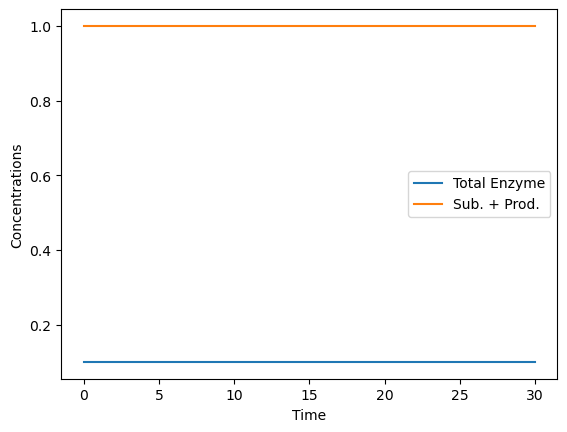

In [2]:
# Plot E + ES
plt.plot(t, E + ES, label="Total Enzyme")

# Plot S + ES + P
plt.plot(t, S + ES + P, label="Sub. + Prod.")

# Prettify the plot
plt.xlabel("Time")
plt.ylabel("Concentrations")
plt.legend()

plt.show()